In [1]:
# ============================================================
# Task 5: Multi-Asset Connectivity Analysis
# ============================================================


import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

ASSET_METADATA_PATH = "asset_metadata.csv"
ASSET_CONNECTIVITY_PATH = "asset_connectivity.csv"


asset_df = pd.read_csv(ASSET_METADATA_PATH)
conn_df = pd.read_csv(ASSET_CONNECTIVITY_PATH)

print("Assets:", asset_df.shape)
print("Connections:", conn_df.shape)
asset_df.head()

Assets: (62, 9)
Connections: (57, 4)


,asset_id,site_id,building_id,asset_name,asset_type,manufacturer,installation_date,capacity,parent_asset_id
0,SITE-01-BLDG-01-AST-000,SITE-01,SITE-01-BLDG-01,Chiller-SITE-01-BLDG-01-000,Chiller,Honeywell,2015-04-13,677.93,NaN
1,SITE-01-BLDG-01-AST-001,SITE-01,SITE-01-BLDG-01,Pump-SITE-01-BLDG-01-001,Pump,Trane,2017-09-30,33.00,NaN
2,SITE-01-BLDG-01-AST-002,SITE-01,SITE-01-BLDG-01,AHU-SITE-01-BLDG-01-002,AHU,Honeywell,2016-02-24,10005.63,SITE-01-BLDG-01-AST-000
3,SITE-01-BLDG-01-AST-003,SITE-01,SITE-01-BLDG-01,EnvSensor-SITE-01-BLDG-01-003,EnvSensor,Siemens,2015-12-23,NaN,SITE-01-BLDG-01-AST-005
4,SITE-01-BLDG-01-AST-004,SITE-01,SITE-01-BLDG-01,EnergyMeter-SITE-01-BLDG-01-004,EnergyMeter,Carrier,2015-05-11,NaN,SITE-01-BLDG-01-AST-005


In [2]:
# Asset Hierarchy 

def build_combined_hierarchy(asset_meta_df):

    hierarchy = {}

    for site_id, site_group in asset_meta_df.groupby("site_id"):
        hierarchy[site_id] = {}

        for building_id, bldg_group in site_group.groupby("building_id"):
            hierarchy[site_id][building_id] = {}

            # Build a quick lookup: asset_id -> row, and parent -> [children]
            bldg_assets = bldg_group.set_index("asset_id")
            children_map = {}
            for _, row in bldg_group.iterrows():
                if pd.notna(row["parent_asset_id"]):
                    children_map.setdefault(row["parent_asset_id"], []).append(row["asset_id"])

            def build_node(asset_id):
                row = bldg_assets.loc[asset_id]
                return {
                    "asset_id": asset_id,
                    "asset_type": row["asset_type"],
                    "children": [build_node(c) for c in children_map.get(asset_id, [])],
                }

            # Root assets = no parent within this building (Chiller/Pump, or orphans)
            root_ids = bldg_group[bldg_group["parent_asset_id"].isna()]["asset_id"].tolist()
            # also catch assets whose parent lives outside this building (edge case) — treat as root too
            for aid in bldg_group["asset_id"]:
                parent = bldg_assets.loc[aid, "parent_asset_id"]
                if pd.notna(parent) and parent not in bldg_assets.index and aid not in root_ids:
                    root_ids.append(aid)

            for root_id in root_ids:
                hierarchy[site_id][building_id][root_id] = build_node(root_id)

    return hierarchy


combined_hierarchy = build_combined_hierarchy(asset_df)


def print_combined_hierarchy(hierarchy):
    def print_node(node, indent):
        print(f"{'  ' * indent}└── {node['asset_id']}  ({node['asset_type']})")
        for child in node["children"]:
            print_node(child, indent + 1)

    for site, buildings in hierarchy.items():
        print(site)
        for bldg, roots in buildings.items():
            print(f"  └── {bldg}")
            if not roots:
                print("        (no root assets found)")
            for root_id, node in roots.items():
                print_node(node, 3)


print_combined_hierarchy(combined_hierarchy)

SITE-01
  └── SITE-01-BLDG-01
      └── SITE-01-BLDG-01-AST-000  (Chiller)
        └── SITE-01-BLDG-01-AST-002  (AHU)
        └── SITE-01-BLDG-01-AST-008  (EnvSensor)
        └── SITE-01-BLDG-01-AST-012  (AHU)
      └── SITE-01-BLDG-01-AST-001  (Pump)
      └── SITE-01-BLDG-01-AST-005  (Chiller)
        └── SITE-01-BLDG-01-AST-003  (EnvSensor)
        └── SITE-01-BLDG-01-AST-004  (EnergyMeter)
        └── SITE-01-BLDG-01-AST-007  (EnvSensor)
      └── SITE-01-BLDG-01-AST-010  (Chiller)
        └── SITE-01-BLDG-01-AST-009  (EnergyMeter)
      └── SITE-01-BLDG-01-AST-013  (Chiller)
        └── SITE-01-BLDG-01-AST-006  (EnvSensor)
        └── SITE-01-BLDG-01-AST-011  (EnergyMeter)
  └── SITE-01-BLDG-02
      └── SITE-01-BLDG-02-AST-001  (Pump)
        └── SITE-01-BLDG-02-AST-004  (AHU)
      └── SITE-01-BLDG-02-AST-002  (Pump)
      └── SITE-01-BLDG-02-AST-003  (Chiller)
      └── SITE-01-BLDG-02-AST-006  (Pump)
      └── SITE-01-BLDG-02-AST-007  (Pump)
        └── SITE-01-BLDG-02-AST-005

In [6]:
  # %% Cell 4 — Functional hierarchy graph (parent_asset_id chain: Chiller/Pump -> AHU/Sensor/Meter)
hierarchy_graph = nx.DiGraph()

for _, row in asset_df.iterrows():
    hierarchy_graph.add_node(row["asset_id"], asset_type=row["asset_type"], site_id=row["site_id"])
    if pd.notna(row["parent_asset_id"]) and row["parent_asset_id"] in valid_asset_ids:
        hierarchy_graph.add_edge(row["parent_asset_id"], row["asset_id"])

print("Functional hierarchy graph:")
print(f"  Nodes: {hierarchy_graph.number_of_nodes()}")
print(f"  Edges: {hierarchy_graph.number_of_edges()}")

roots = [n for n in hierarchy_graph.nodes if hierarchy_graph.in_degree(n) == 0
         and hierarchy_graph.out_degree(n) > 0]
print(f"\nRoot assets (no parent, has children): {len(roots)}")
for r in roots[:10]:
    children = list(hierarchy_graph.successors(r))
    print(f"  {r} ({hierarchy_graph.nodes[r]['asset_type']}) -> {children}")

Functional hierarchy graph:
  Nodes: 62
  Edges: 37

Root assets (no parent, has children): 17
  SITE-01-BLDG-01-AST-000 (Chiller) -> ['SITE-01-BLDG-01-AST-002', 'SITE-01-BLDG-01-AST-008', 'SITE-01-BLDG-01-AST-012']
  SITE-01-BLDG-01-AST-005 (Chiller) -> ['SITE-01-BLDG-01-AST-003', 'SITE-01-BLDG-01-AST-004', 'SITE-01-BLDG-01-AST-007']
  SITE-01-BLDG-01-AST-013 (Chiller) -> ['SITE-01-BLDG-01-AST-006', 'SITE-01-BLDG-01-AST-011']
  SITE-01-BLDG-01-AST-010 (Chiller) -> ['SITE-01-BLDG-01-AST-009']
  SITE-01-BLDG-02-AST-008 (Pump) -> ['SITE-01-BLDG-02-AST-000']
  SITE-01-BLDG-02-AST-001 (Pump) -> ['SITE-01-BLDG-02-AST-004']
  SITE-01-BLDG-02-AST-007 (Pump) -> ['SITE-01-BLDG-02-AST-005']
  SITE-02-BLDG-01-AST-004 (Pump) -> ['SITE-02-BLDG-01-AST-000', 'SITE-02-BLDG-01-AST-001']
  SITE-02-BLDG-01-AST-006 (Pump) -> ['SITE-02-BLDG-01-AST-002', 'SITE-02-BLDG-01-AST-003', 'SITE-02-BLDG-01-AST-007', 'SITE-02-BLDG-01-AST-009']
  SITE-02-BLDG-01-AST-005 (Chiller) -> ['SITE-02-BLDG-01-AST-008']


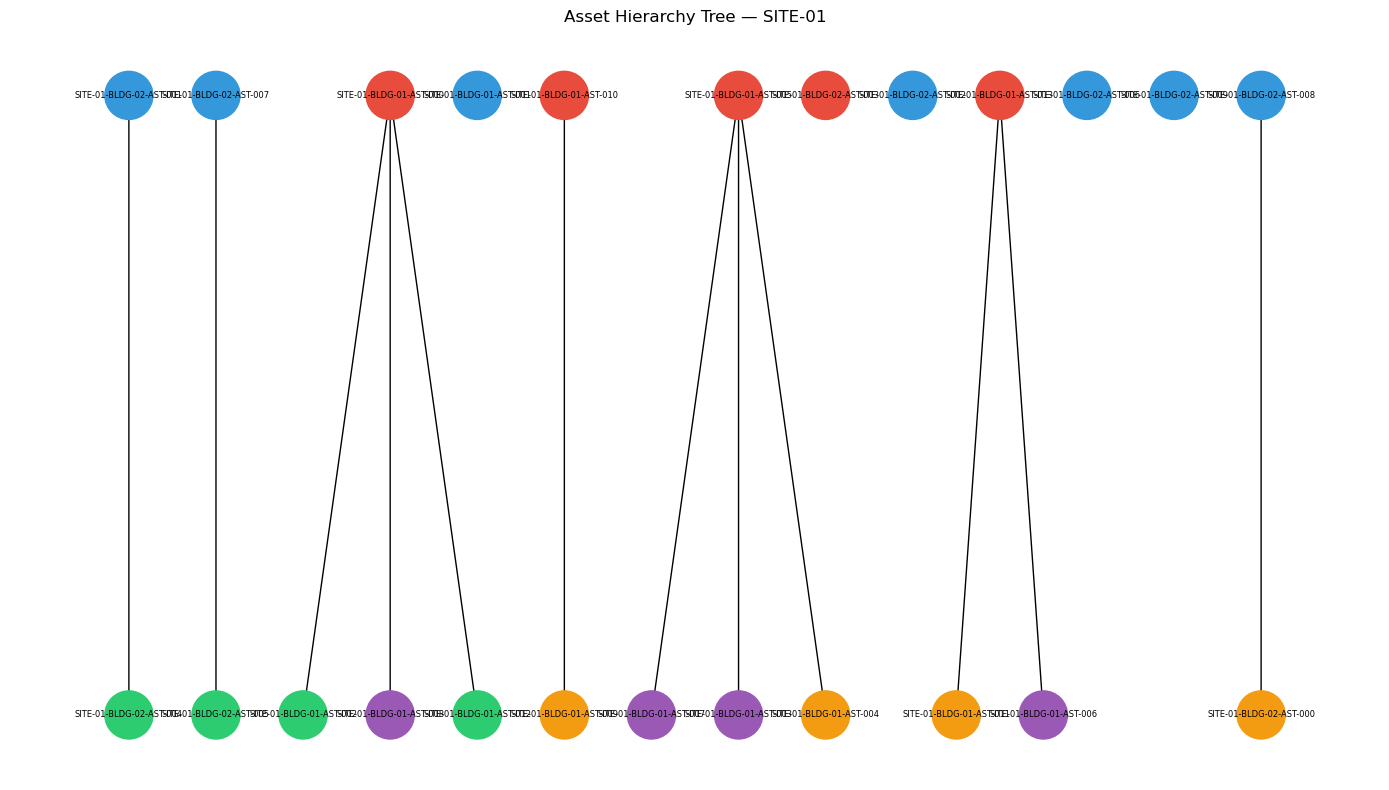

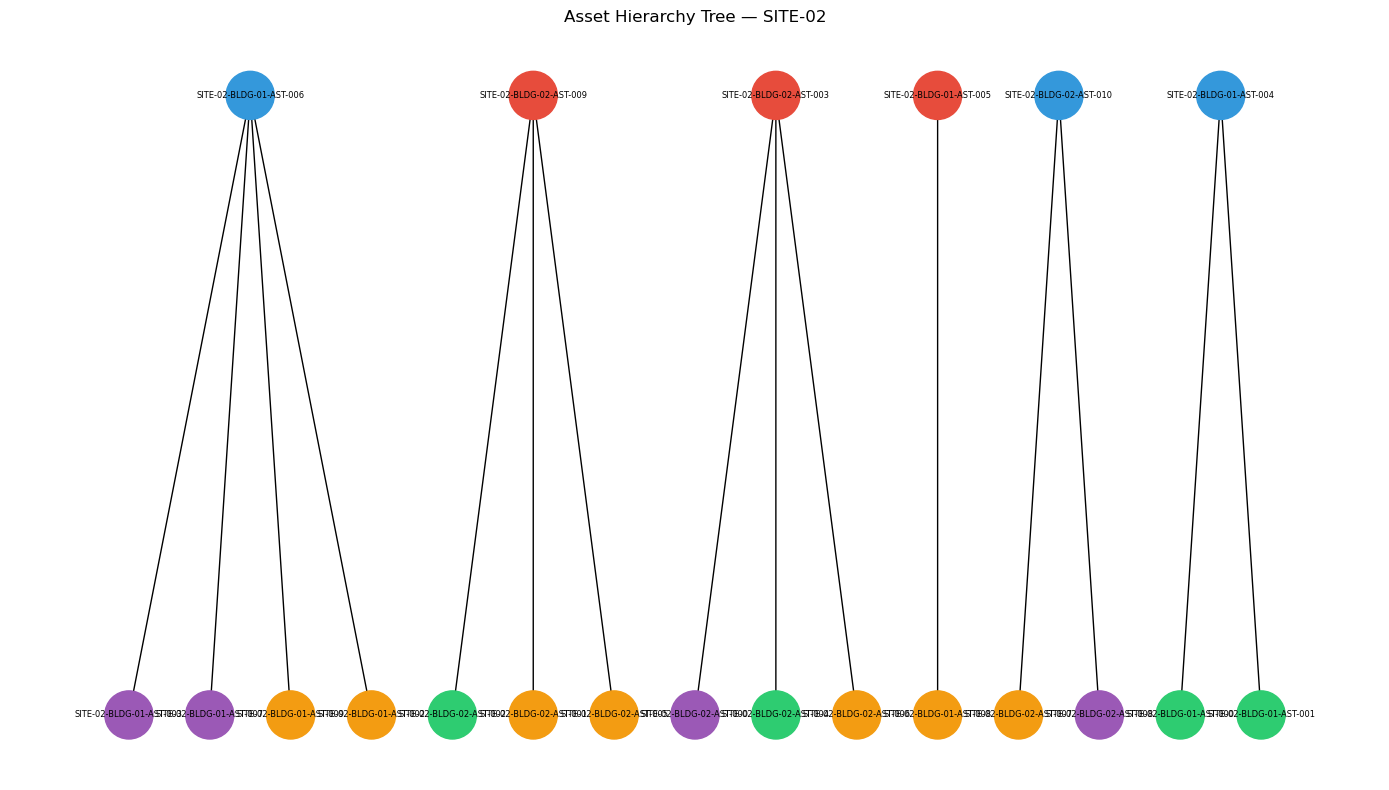

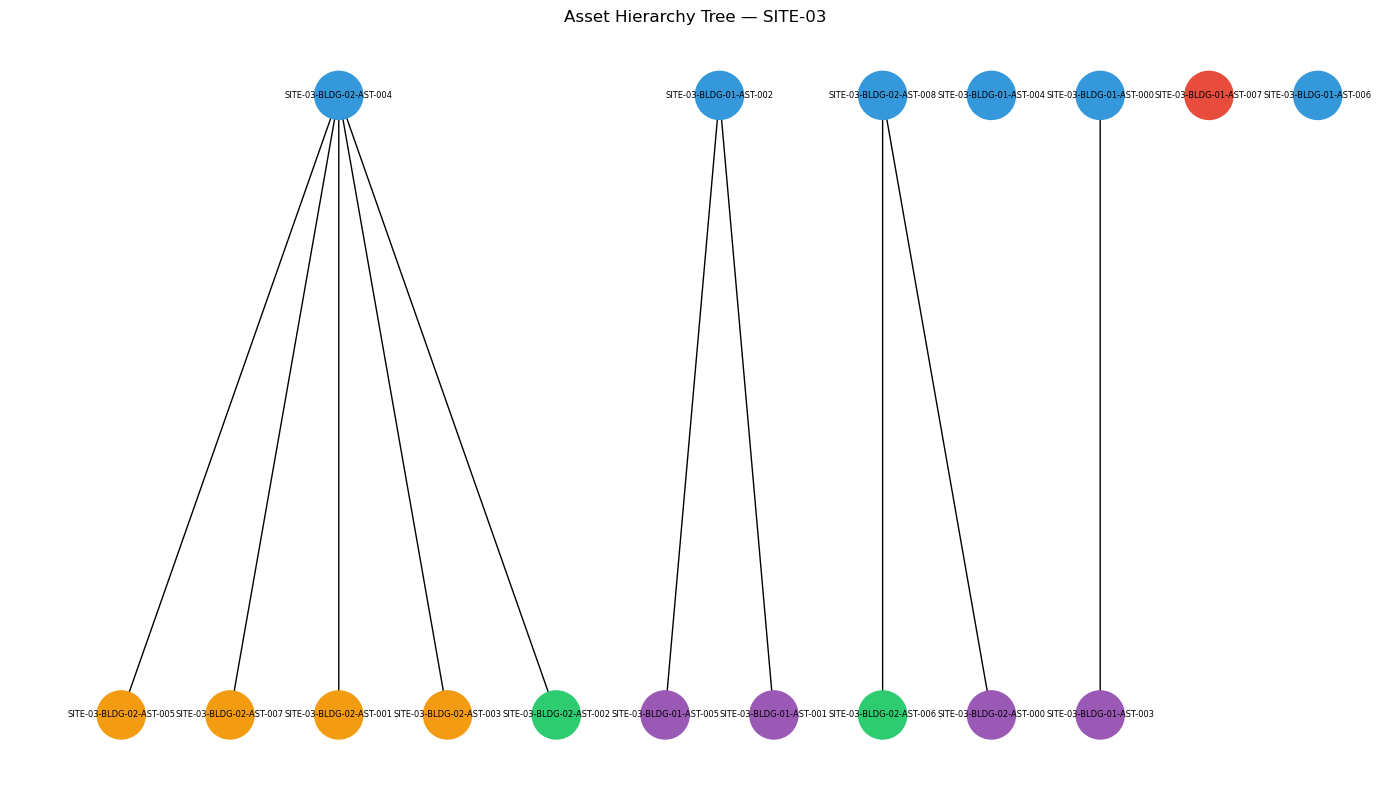

In [7]:
# Asset hierarchy visualization (tree layout, functional hierarchy)
def plot_hierarchy_tree(graph, asset_meta_df, site_id, figsize=(14, 8)):
    site_assets = asset_meta_df[asset_meta_df["site_id"] == site_id]["asset_id"].tolist()
    sub = graph.subgraph(site_assets)

    if sub.number_of_edges() == 0:
        print(f"No hierarchy edges to plot for {site_id}")
        return

    try:
        pos = nx.nx_agraph.graphviz_layout(sub, prog="dot")
    except Exception:
        pos = nx.spring_layout(sub, seed=42)

    color_map = {
        "Chiller": "#e74c3c", "Pump": "#3498db", "AHU": "#2ecc71",
        "EnergyMeter": "#f39c12", "EnvSensor": "#9b59b6",
    }
    node_colors = [color_map.get(sub.nodes[n].get("asset_type"), "#95a5a6") for n in sub.nodes]

    # Explicitly create fig/ax and pass ax=ax to avoid the nx.draw internal axstack bug
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_nodes(sub, pos, ax=ax, node_color=node_colors, node_size=1200)
    nx.draw_networkx_labels(sub, pos, ax=ax, font_size=6)
    nx.draw_networkx_edges(sub, pos, ax=ax, arrows=True, arrowsize=12)

    ax.set_title(f"Asset Hierarchy Tree — {site_id}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


for site in asset_df["site_id"].unique():
    plot_hierarchy_tree(hierarchy_graph, asset_df, site)

In [5]:
# Data Quality Assessment
# Requirement: Missing relationships, Duplicate connections, Orphan assets, Invalid parent-child mappings

valid_asset_ids = set(asset_df["asset_id"])

# 1. Invalid parent-child mappings in asset_metadata (parent_asset_id not in asset list)
invalid_parents = asset_df[
    asset_df["parent_asset_id"].notna() &
    ~asset_df["parent_asset_id"].isin(valid_asset_ids)
]

# 2. Missing relationships: assets with no parent AND not a "root" type (Chiller/Pump)
ROOT_TYPES = {"Chiller", "Pump"}
missing_relationship = asset_df[
    asset_df["parent_asset_id"].isna() &
    ~asset_df["asset_type"].isin(ROOT_TYPES)
]

# 3. Orphan assets: appear in neither source nor target of asset_connectivity
connected_ids = set(conn_df["source_asset_id"]) | set(conn_df["target_asset_id"])
orphan_assets = asset_df[~asset_df["asset_id"].isin(connected_ids)]

# 4. Duplicate connections: exact duplicate (source, target, connection_type) rows
duplicate_connections = conn_df[
    conn_df.duplicated(subset=["source_asset_id", "target_asset_id", "connection_type"], keep=False)
]

# 5. Invalid edges: source or target asset_id doesn't exist in asset_metadata at all
invalid_edges = conn_df[
    ~conn_df["source_asset_id"].isin(valid_asset_ids) |
    ~conn_df["target_asset_id"].isin(valid_asset_ids)
]

print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)
print(f"Invalid parent-child mappings (metadata):     {len(invalid_parents)}")
print(f"Assets with missing parent relationship:       {len(missing_relationship)}")
print(f"Orphan assets (no connectivity edges at all):  {len(orphan_assets)}")
print(f"Duplicate connections:                          {len(duplicate_connections)}")
print(f"Invalid edges (unknown asset referenced):       {len(invalid_edges)}")

print("\n--- Invalid edges detail ---")
print(invalid_edges)

print("\n--- Orphan assets detail ---")
print(orphan_assets[["asset_id", "asset_type", "site_id", "building_id"]])

DATA QUALITY REPORT
Invalid parent-child mappings (metadata):     0
Assets with missing parent relationship:       0
Orphan assets (no connectivity edges at all):  7
Duplicate connections:                          6
Invalid edges (unknown asset referenced):       1

--- Invalid edges detail ---
           source_asset_id    target_asset_id connection_type  \
0  SITE-01-BLDG-01-AST-000  UNKNOWN-ASSET-999        Supplies   

   relationship_strength  
0                   0.62  

--- Orphan assets detail ---
                   asset_id asset_type  site_id      building_id
2   SITE-01-BLDG-01-AST-002        AHU  SITE-01  SITE-01-BLDG-01
16  SITE-01-BLDG-02-AST-002       Pump  SITE-01  SITE-01-BLDG-02
17  SITE-01-BLDG-02-AST-003    Chiller  SITE-01  SITE-01-BLDG-02
20  SITE-01-BLDG-02-AST-006       Pump  SITE-01  SITE-01-BLDG-02
23  SITE-01-BLDG-02-AST-009       Pump  SITE-01  SITE-01-BLDG-02
49  SITE-03-BLDG-01-AST-004       Pump  SITE-03  SITE-03-BLDG-01
51  SITE-03-BLDG-01-AST-006       

In [ ]:
# Full Connectivity Graph (all edge types: parent-child + Supplies/Controls/Monitors)
conn_graph = nx.DiGraph()

for _, row in asset_df.iterrows():
    conn_graph.add_node(row["asset_id"], asset_type=row["asset_type"], site_id=row["site_id"],
                         building_id=row["building_id"])

for _, row in conn_clean.iterrows():
    conn_graph.add_edge(
        row["source_asset_id"], row["target_asset_id"],
        connection_type=row["connection_type"],
        weight=row["relationship_strength"],
    )

print(f"Connectivity graph: {conn_graph.number_of_nodes()} nodes, {conn_graph.number_of_edges()} edges")

# Which assets are connected? (any edge in or out)
connected = [n for n in conn_graph.nodes if conn_graph.degree(n) > 0]
isolated = [n for n in conn_graph.nodes if conn_graph.degree(n) == 0]

print(f"\nConnected assets: {len(connected)}")
print(f"Isolated assets (no edges at all): {len(isolated)}")
if isolated:
    print(asset_df[asset_df["asset_id"].isin(isolated)][["asset_id", "asset_type", "site_id"]])

In [ ]:
# %% Cell 6 — Which assets depend on each other? (dependency = target depends on source)
print("Dependency relationships (target depends on source):\n")
dependency_summary = []
for _, row in conn_clean.iterrows():
    dependency_summary.append({
        "dependent_asset": row["target_asset_id"],
        "depends_on": row["source_asset_id"],
        "relationship": row["connection_type"],
        "strength": row["relationship_strength"],
    })
dependency_df = pd.DataFrame(dependency_summary).sort_values("strength", ascending=False)
dependency_df.head(15)

In [ ]:
# %% Cell 7 — Failure Impact Analysis
# Determine all downstream assets affected if a given asset fails, using graph reachability

def downstream_impact(graph, failed_asset, connection_types=None):
    """Return all assets reachable (downstream) from failed_asset, optionally filtered by edge type."""
    if failed_asset not in graph:
        return []
    if connection_types:
        sub_edges = [(u, v) for u, v, d in graph.edges(data=True)
                     if d.get("connection_type") in connection_types]
        sub = nx.DiGraph()
        sub.add_nodes_from(graph.nodes(data=True))
        sub.add_edges_from(sub_edges)
        graph = sub
    return list(nx.descendants(graph, failed_asset))


def failure_impact_report(graph, asset_meta_df, failed_asset_id):
    if failed_asset_id not in graph:
        print(f"Asset {failed_asset_id} not found in graph.")
        return

    impacted = downstream_impact(graph, failed_asset_id)
    row = asset_meta_df[asset_meta_df["asset_id"] == failed_asset_id].iloc[0]

    print("=" * 60)
    print(f"FAILURE IMPACT ANALYSIS: {failed_asset_id} ({row['asset_type']})")
    print("=" * 60)
    print(f"Site: {row['site_id']} | Building: {row['building_id']}")
    print(f"\nDirectly impacted downstream assets: {len(impacted)}")

    if impacted:
        impacted_df = asset_meta_df[asset_meta_df["asset_id"].isin(impacted)][
            ["asset_id", "asset_type", "building_id"]
        ]
        print(impacted_df.to_string(index=False))

        type_counts = impacted_df["asset_type"].value_counts()
        print("\nImpact by asset type:")
        print(type_counts.to_string())

        # Simple operational-impact heuristic by asset type
        impact_map = {
            "AHU": "Loss of conditioned air supply to served zones — occupant comfort risk.",
            "EnvSensor": "Loss of environmental monitoring — reduced visibility into space conditions.",
            "EnergyMeter": "Loss of energy usage visibility for billing/optimization.",
            "Pump": "Loss of fluid circulation — risk of downstream equipment overheating.",
            "Chiller": "Loss of cooling capacity for entire served zone.",
        }
        print("\nPotential operational impact:")
        for t in type_counts.index:
            print(f"  - {t}: {impact_map.get(t, 'Operational disruption expected.')}")

        print("\nRecommended mitigation strategies:")
        print("  1. Activate redundant/backup unit if available for the failed asset.")
        print("  2. Prioritize field technician dispatch based on number of downstream assets impacted.")
        print(f"  3. Notify facility ops for {row['building_id']} of potential comfort/energy-monitoring gaps.")
        print("  4. Increase monitoring frequency on directly downstream assets during outage window.")
    else:
        print("No downstream dependencies found — isolated failure with no propagation.")
    print()


# Example: run for a Chiller and a Pump, as specified in the task
chillers = asset_df[asset_df["asset_type"] == "Chiller"]["asset_id"].tolist()
pumps = asset_df[asset_df["asset_type"] == "Pump"]["asset_id"].tolist()

if chillers:
    failure_impact_report(conn_graph, asset_df, chillers[0])
if pumps:
    failure_impact_report(conn_graph, asset_df, pumps[0])

In [ ]:
# %% Cell 8 — Dependency graph / network visualization
def plot_site_graph(graph, asset_meta_df, site_id, figsize=(12, 8)):
    site_assets = asset_meta_df[asset_meta_df["site_id"] == site_id]["asset_id"].tolist()
    sub = graph.subgraph(site_assets)

    color_map = {
        "Chiller": "#e74c3c", "Pump": "#3498db", "AHU": "#2ecc71",
        "EnergyMeter": "#f39c12", "EnvSensor": "#9b59b6",
    }
    node_colors = [color_map.get(sub.nodes[n].get("asset_type"), "#95a5a6") for n in sub.nodes]

    plt.figure(figsize=figsize)
    pos = nx.spring_layout(sub, seed=42, k=0.8)
    nx.draw_networkx_nodes(sub, pos, node_color=node_colors, node_size=800, alpha=0.9)
    nx.draw_networkx_labels(sub, pos, font_size=7)
    nx.draw_networkx_edges(sub, pos, arrows=True, arrowsize=15, alpha=0.5)

    edge_labels = nx.get_edge_attributes(sub, "connection_type")
    nx.draw_networkx_edge_labels(sub, pos, edge_labels=edge_labels, font_size=6)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=t)
               for t, c in color_map.items()]
    plt.legend(handles=handles, loc="best", title="Asset Type")
    plt.title(f"Asset Connectivity Graph — {site_id}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


for site in asset_df["site_id"].unique():
    plot_site_graph(conn_graph, asset_df, site)

In [ ]:
# %% Cell 10 — Bonus: Graph query helper functions (natural-language-style queries)

def assets_connected_to(graph, asset_id):
    if asset_id not in graph:
        return []
    return list(nx.node_connected_component(graph.to_undirected(), asset_id) - {asset_id})

def downstream_impacted_by(graph, asset_id):
    return downstream_impact(graph, asset_id)

def assets_under_site(asset_meta_df, site_id):
    return asset_meta_df[asset_meta_df["site_id"] == site_id]["asset_id"].tolist()

def isolated_assets(graph):
    return [n for n in graph.nodes if graph.degree(n) == 0]


# Example query runs
example_chiller = chillers[0] if chillers else None
example_ahu = asset_df[asset_df["asset_type"] == "AHU"]["asset_id"].iloc[0]
example_site = asset_df["site_id"].iloc[0]

print("Q: Show all assets connected to", example_chiller)
print(assets_connected_to(conn_graph, example_chiller))

print("\nQ: Identify all downstream assets impacted by", example_ahu, "failure")
print(downstream_impacted_by(conn_graph, example_ahu))

print("\nQ: List all assets under", example_site)
print(assets_under_site(asset_df, example_site))

print("\nQ: Find isolated assets with no parent/child relationships")
print(isolated_assets(conn_graph))

In [ ]:
# Summary report
print("=" * 60)
print("TASK 5 — CONNECTIVITY ANALYSIS SUMMARY REPORT")
print("=" * 60)
print(f"Total assets:                 {len(asset_df)}")
print(f"Total sites:                  {asset_df['site_id'].nunique()}")
print(f"Total buildings:              {asset_df['building_id'].nunique()}")
print(f"Total connectivity edges:     {len(conn_clean)} (raw: {len(conn_df)})")
print(f"Isolated assets:              {len(isolated_assets(conn_graph))}")
print(f"Orphan assets (metadata):     {len(orphan_assets)}")
print(f"Duplicate connections found:  {len(duplicate_connections)}")
print(f"Invalid edges found:          {len(invalid_edges)}")
print(f"Invalid parent mappings:      {len(invalid_parents)}")
print("\nAssumptions:")
print(" - Chiller and Pump asset types are treated as 'root' assets (no expected parent).")
print(" - Edges referencing unknown asset_ids were excluded from graph analysis but reported")
print("   separately under Data Quality Assessment.")
print(" - Failure impact is computed via directed-graph descendant reachability on the")
print("   full connectivity graph (parent-child + Supplies/Controls/Monitors edges).")